In this ipython notebook, we want to solve the switching optimal control problem in discrete time. As example, we choose K = 10, A = [[1, 0],[0, 2]], B1 = [1, 0] and B2 = [0, 1], as described in [Zuazua '10].

In [1]:
import numpy as np
import random
from tqdm import trange
import matplotlib.pyplot as plt
#np.seterr(all='raise')

We first initialize the technical parameters...

In [2]:
switchingCost = .1 #cost of switching up or down a level
learningRate = .5
gamma = 1
runningFactor = .1
evaluateEvery = 10000
itNumber = 10000000 #number of learning iterations
exploreRate = .2 #rate at which exploration happens
learnerType = 'QLEARN' #accepts 'SARSA' or 'QLEARN'

... and the model parameters. To facilitate matters, we fully discretize the control space.

In [3]:
T = 1 #final time
K = 5#10 #number of time steps
dt = T/K #time step

y0 = np.array([2, -3])
ybar = np.array([-4, 7])

A = np.array([[1,0],[0,2]])
B = [np.array([1,0]), np.array([0,1])] #able to switch
umax = 20
controlSpace = np.array([-20, -15, -10, -5, 0, 5, 10, 15, 20])#np.arange(-umax, umax+1)

To setup a Reinforcement Learning algorithm, we have to define a state space first, which is the set of all possible states the model can be in.

In [4]:
N = len(y0)
tt = np.linspace(0, K, K+1)

xSpace = np.linspace(y0[0] - T*(1+umax), y0[0] + T*(1+umax), 10)
ySpace = np.linspace(y0[1] - T*(2+umax), y0[1] + T*(2+umax), 10)

Now we can define the costs and the state transitions. a is the currently active control index, b the control index we choose to activate next

In [5]:
def runningCost(state, action):
    (x, a) = state
    (u, b) = action
    return switchingCost*(a!=b)*(a!=None) + runningFactor*np.linalg.norm(x-ybar)**2

def finalCost(state):
    (x, a) = state
    return np.linalg.norm(x-ybar)**2 #final cost

def transition(state, action):
    (x, a) = state
    (u, b) = action
    yNew = x + dt*(A@x + B[b]*u)
    return (yNew, b)

This allows us, given a set of control actions (here referred to as "policy"), to define a model simulator.

In [6]:
def simulator(x0, policy):
    x = np.zeros((N,K+1))
    r = np.zeros(K+1)
    u = np.zeros(K)
    x[:,0] = x0
    state = (x0, 0, None)
    for n in range(K):
        action = policy[n]
        newState = transition(state, action)
        xnew = newState[0]
        rnew = runningCost(state, action)
        x[:,n+1] = xnew
        u[n] = action
        r[n] = rnew
        state = newState
    r[K] = finalCost(state)
    return (x, u, r)

The Q-algorithm needs the so-called Q function, which in our case assigns to a state (m, x, a) (where m is the time, x the state and a the current control index) and an action (u, b) (where u is the level of the control and b the index it is active on) the value of that state-action pair. The u space has been fully discretized, and x is handled using state aggregation. If m=0, there is no currently active control, which is why we add the entries with a=None separately.

In [7]:
def discreteBasis(xSpace, ySpace, controlSpace, K):
    indSet0 = {(m, x, y, a, u, b) for m in range(1, K) for x in xSpace for y in ySpace for a in [0, 1] for u in controlSpace for b in [0, 1]}
    indSet = indSet0.union({(0, x, y, None, u, b) for x in xSpace for y in ySpace for u in controlSpace for b in [0, 1]})
    return indSet

Now we are ready to define a RL agent. The functions xInStateSpace and yInStateSpace are state aggregators, which assign to any value the closest math to an entry of xSpace and ySpace, respectively.

In [8]:
### Learner
class Learner:
    def __init__(self, learnerType, learningRate, exploreRate, evaluateEvery):
        self.learnerType = learnerType
        self.learningRate = learningRate
        self.exploreRate = exploreRate
        self.evaluateEvery = evaluateEvery
        self.polyBasis = discreteBasis(xSpace, ySpace, controlSpace, K)
        self.theta = {ind:np.random.rand() for ind in self.polyBasis} #initialize the Q function randomly
        self.totalIt = 0
        self.totalDeltaArr = []
        self.totalCostArr = []
        self.totalEvalArr = []
        self.finalEvalArr = []

    def approxQ(self, m, state, action):
        (x, a) = state
        (u, b) = action
        xInStateSpace = min(xSpace, key = lambda t: abs(t-x[0])) #for state aggregation
        yInStateSpace = min(ySpace, key = lambda t: abs(t-x[1]))
        val = self.theta[(m, xInStateSpace, yInStateSpace, a, u, b)]
        return val

    def greedy(self, m, state):
        (x, a) = state
        umin = [None, None]
        fumin = [None, None]
        for b in (0, 1):
            umin[b] = min(controlSpace, key = lambda u: self.approxQ(m, state, (u, b)))
            fumin[b] = self.approxQ(m, state, (umin[b], b))
        if a == None:
            a = 0 #initially, a = None
        if fumin[a] > fumin[1-a]: #in case of a tie, don't switch
            return (umin[1-a], 1-a)
        else:
            return (umin[a], a)

    def findMinQ(self, m, state):
        (x, a) = state
        umin = self.greedy(m, state) #min(staircase(a), key = lambda u: self.approxQ(m, state, u))
        fumin = self.approxQ(m, state, umin)
        return fumin
        
    def Qsimulator(self, x0):
        x = np.zeros((N,K+1))
        r = np.zeros(K+1)
        u = [np.zeros(K),np.zeros(K)]
        x[:,0] = x0
        state = (x0, None)
        for n in range(K):
            action = self.greedy(n, state)
            newState = transition(state, action)
            xnew = newState[0]
            rnew = runningCost(state, action)
            x[:,n+1] = xnew
            u[action[1]][n] = action[0]
            r[n] = rnew
            state = newState
        r[K] = finalCost(state)
        return (x, u, r)
    
    def learn(self, itNumber):
        deltaArr = np.zeros(itNumber)
        for k in trange(itNumber): #trange adds a progress bar
            if (k+self.totalIt) % self.evaluateEvery == 0:
                self.evaulate()

            deltaMax = -np.inf
            state = (y0, None)
            
            totalCost = 0
            for m in range(K): #perform one sweep
                if np.random.random() < self.exploreRate: #Exploration
                    (x, a) = state
                    action = (random.sample(sorted(controlSpace),1)[0], random.randint(0, 1))
                else:
                    action = self.greedy(m, state)
                
                newState = transition(state, action)
                
                rnew = runningCost(state, action)
                totalCost += rnew
                
                if m == K-1:
                    totalCost += finalCost(newState)
                    #print(totalCost)
                    delta = rnew + gamma*finalCost(newState) - self.approxQ(m, state, action)
                else:
                    match learnerType: 
                        case 'QLEARN':
                            delta = rnew + gamma*self.findMinQ(m+1, newState) - self.approxQ(m, state, action)
                            deltaMax = max(deltaMax, abs(delta))
                        case 'QTLEARN':
                            delta = [rnew + gamma*self.findMinQ(mm+1, newState) - self.approxQ(mm, state, action) for mm in range(K-1)]
                            deltaMax = max(deltaMax, max(list(map(abs, delta))))
                        case 'SARSA':
                            delta = rnew + gamma*self.approxQ(m+1, newState, action) - self.approxQ(m, state, action)
                            deltaMax = max(deltaMax, abs(delta))
                    #print(delta)
                
                (x, a) = state
                (u, b) = action
                
                xInStateSpace = min(xSpace, key = lambda t: abs(t-x[0])) #for state aggregation
                yInStateSpace = min(ySpace, key = lambda t: abs(t-x[1]))
                if not(m == K-1) and learnerType == 'QTLEARN':
                    for mm in range(K-1):
                        self.theta[(mm, xInStateSpace, yInStateSpace, a, u, b)] += self.learningRate*delta[m]#/np.sqrt(1 + k/20)
                else:
                    self.theta[(m, xInStateSpace, yInStateSpace, a, u, b)] += self.learningRate*delta#/np.sqrt(1 + k/20)
                state =  newState
            #print('deltaMax =', deltaMax)
            deltaArr[k] = deltaMax
            self.totalCostArr.append(totalCost)
        self.totalIt += itNumber
        self.totalDeltaArr.extend(deltaArr)
    
    def evaulate(self):
        *_, r = self.Qsimulator(y0)
        self.totalEvalArr.append(sum(r))
        self.finalEvalArr.append(r[-1])
    
    def makePictures(self):
        (y, u, r) = self.Qsimulator(y0)

        plt.plot(tt, np.hstack((u[0],u[0][-1])), drawstyle='steps-post', label='u1') #show learned control
        plt.plot(tt, np.hstack((u[1],u[1][-1])), drawstyle='steps-post', label='u2') #show learned control
        plt.xlabel('t')
        plt.ylabel('u(t)')
        plt.legend()
        plt.title('Control over time')
        plt.show()

        plt.plot(tt, y[0,:]) #show learned solution
        plt.plot(tt, y[1,:])
        plt.xlabel('k')
        plt.ylabel('x(k)')
        plt.title('Solution over time')
        plt.show()

        #plt.semilogy(self.totalDeltaArr) #show evolution of delta
        #plt.xlabel('iteration')
        #plt.ylabel('deltaMax')
        #plt.show()
        
        #plt.semilogy(self.totalCostArr) #show evolution of the costs during training
        #plt.xlabel('iteration')
        #plt.ylabel('costs per episode')
        #plt.show()

        plt.plot(self.totalEvalArr, label='total') #show evolution of the evaluated costs during training
        plt.plot(self.finalEvalArr, label='final')
        plt.xlabel('iteration')
        plt.ylabel('cost')
        plt.title('Evaluated costs per episode')
        plt.legend()
        plt.show()

        

Initialize and train a first agent:

In [9]:
myQLearner = Learner('QLEARN', learningRate, exploreRate, evaluateEvery)
myQLearner.learn(itNumber)

100%|██████████| 10000000/10000000 [5:25:26<00:00, 512.14it/s]  


Show the results: the structure of the control the agent has learned, the corresponding optimal solution, and the evolution of the evaluated costs during training. If we set the switching costs to zero, the control still steers the state towards zero, but becomes more erratic.

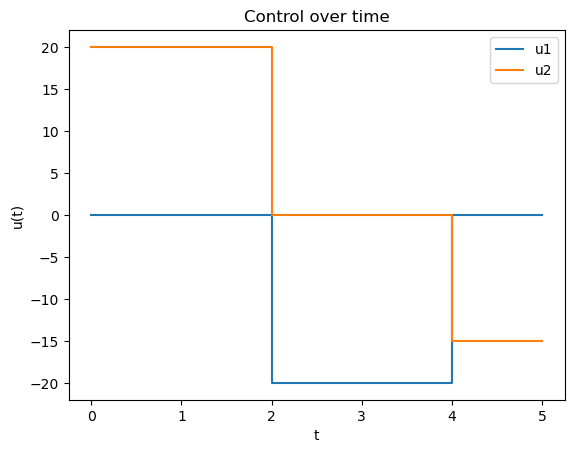

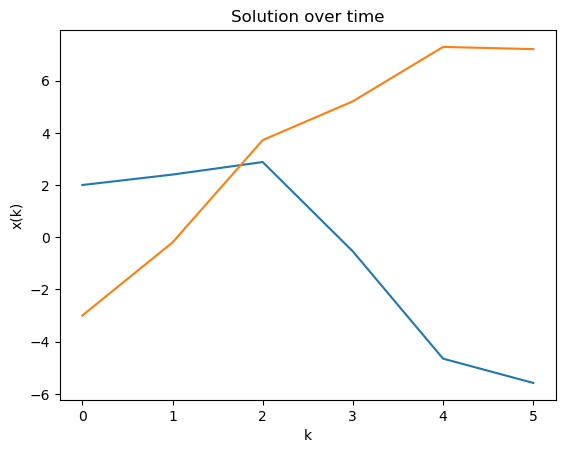

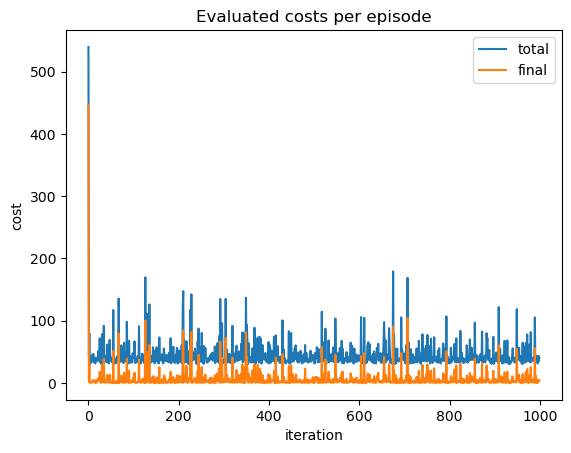

In [10]:
myQLearner.makePictures()